📈 Analizando Muestra Nº 7613 | Segmento: 197306_seg_0 | Clase: 0


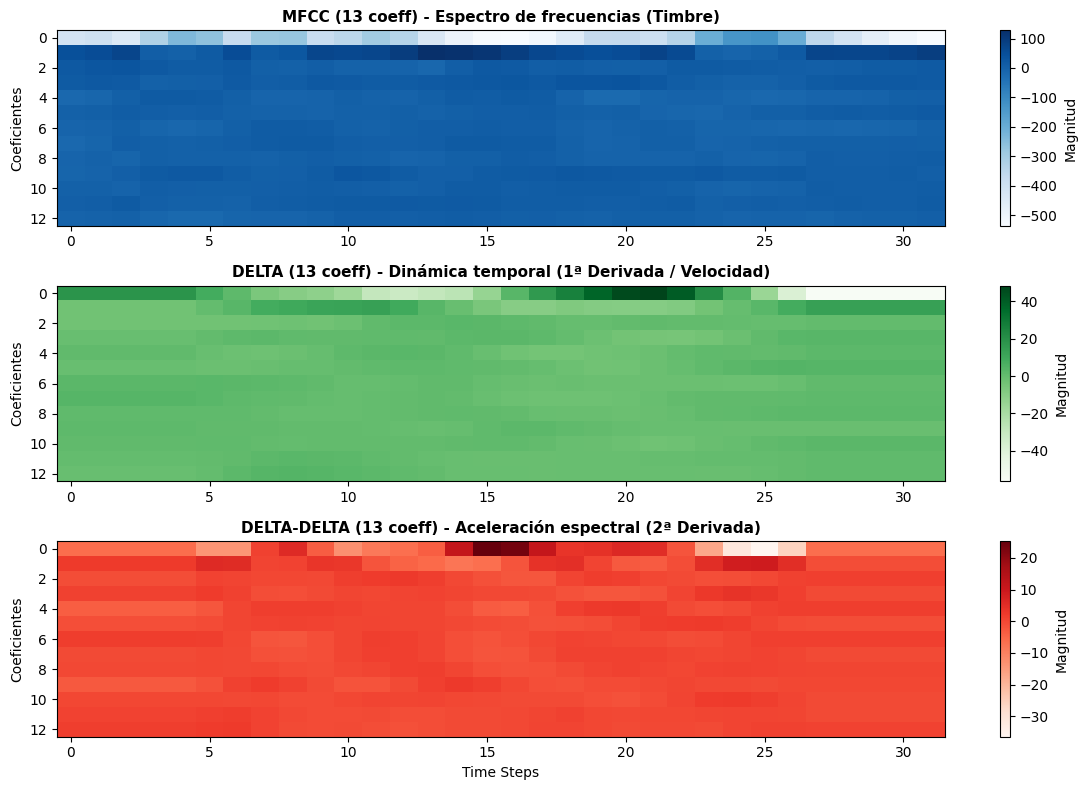

💾 Guardado Mapa de Calor en: C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\graphs_results_experiment_random\heatmaps_197306_seg_0.png


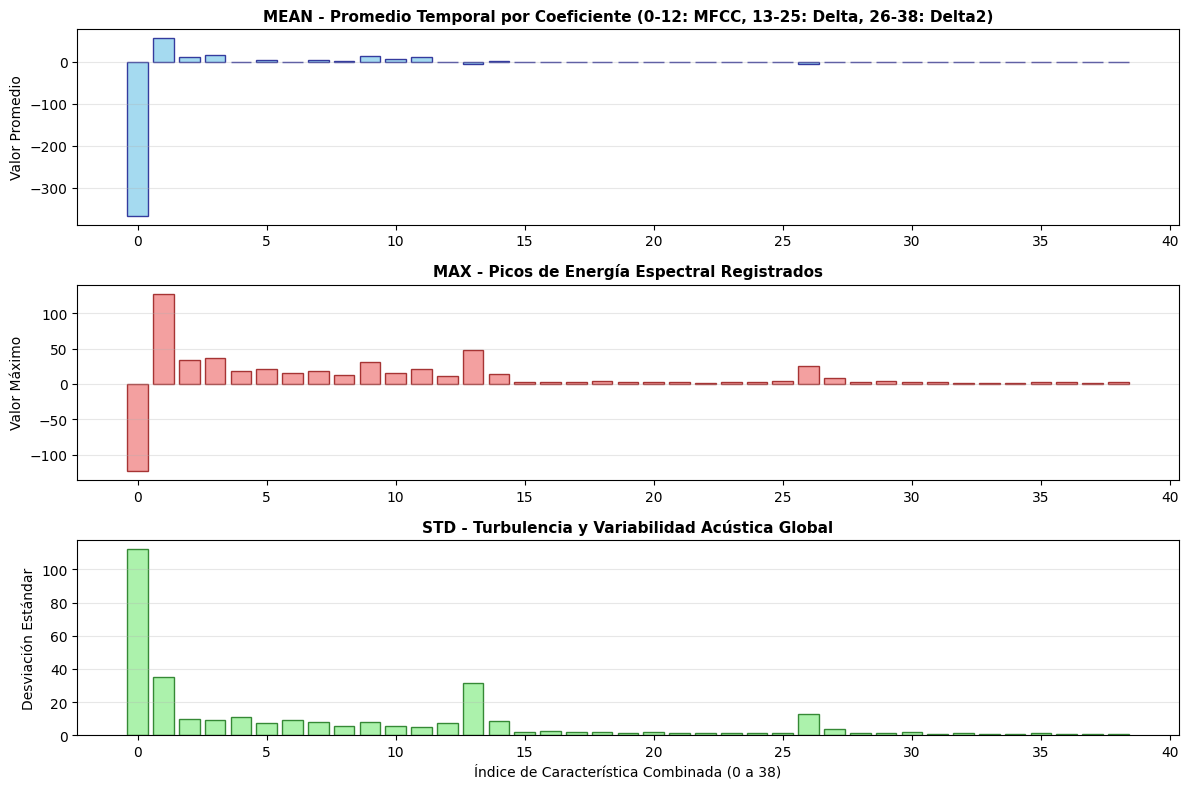

💾 Guardado Gráfico de Barras de Pooling en: C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\graphs_results_experiment_random\pooling_bars_197306_seg_0.png


In [4]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Parámetros e infraestructura de rutas
SAMPLE_RATE = 16000
N_MFCC = 13
PATH_AUDIOS_COUGHVID = r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\DATA"
PATH_AUDIOS_FSD50K = r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\FSD50K_DATA\FSD50K.dev_audio\FSD50K_negative_class_dataset"
PATH_OUTPUT_GRAPHS = r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\graphs_results_experiment_random"

os.makedirs(PATH_OUTPUT_GRAPHS, exist_ok=True)

# 1. Cargar metadatos para mapear los segmentos reales
df_train = pd.read_csv(r"C:\Users\Usuario\Desktop\UNI MARINA\master\TFM\TFM_resp_dis\metadata_splits_experiment_random\metadata_train.csv")

# 2. Seleccionar una muestra aleatoria para inspeccionar
sample_idx = np.random.randint(0, len(df_train))
row = df_train.iloc[sample_idx]

uuid_orig = str(row['original_uuid'])
uuid_seg = str(row['uuid_segmento'])
label = row['label']
start = float(row['start_time'])
end = float(row['end_time'])

# Enrutamiento dinámico al archivo de audio real
if row['dataset_origin'] == 'FSD50K':
    audio_path = os.path.join(PATH_AUDIOS_FSD50K, f"{uuid_orig}.wav")
else:
    audio_path = os.path.join(PATH_AUDIOS_COUGHVID, f"{uuid_orig}.wav")

print(f"📈 Analizando Muestra Nº {sample_idx} | Segmento: {uuid_seg} | Clase: {label}")

# 3. Cargar el segmento de audio exacto y extraer características dinámicas para el plot
y, sr = librosa.load(audio_path, sr=SAMPLE_RATE, offset=start, duration=(end - start))
display(Audio(y, rate=sr))

mfcc = librosa.feature.mfcc(y=y, sr=SAMPLE_RATE, n_mfcc=N_MFCC)
delta = librosa.feature.delta(mfcc)
delta2 = librosa.feature.delta(mfcc, order=2)

# =====================================================================
# 📊 GRÁFICA 1: MAPAS DE CALOR (MFCC + DELTA + DELTA-DELTA)
# =====================================================================
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

im0 = axes[0].imshow(mfcc, aspect='auto', cmap='Blues', interpolation='nearest')
axes[0].set_title('MFCC (13 coeff) - Espectro de frecuencias (Timbre)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Coeficientes')
plt.colorbar(im0, ax=axes[0], label='Magnitud')

im1 = axes[1].imshow(delta, aspect='auto', cmap='Greens', interpolation='nearest')
axes[1].set_title('DELTA (13 coeff) - Dinámica temporal (1ª Derivada / Velocidad)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Coeficientes')
plt.colorbar(im1, ax=axes[1], label='Magnitud')

im2 = axes[2].imshow(delta2, aspect='auto', cmap='Reds', interpolation='nearest')
axes[2].set_title('DELTA-DELTA (13 coeff) - Aceleración espectral (2ª Derivada)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Coeficientes')
axes[2].set_xlabel('Time Steps')
plt.colorbar(im2, ax=axes[2], label='Magnitud')

plt.tight_layout()
path_save_heatmaps = os.path.join(PATH_OUTPUT_GRAPHS, f"heatmaps_{uuid_seg}.png")
plt.savefig(path_save_heatmaps, dpi=300, bbox_inches='tight')
plt.show()
print(f"💾 Guardado Mapa de Calor en: {path_save_heatmaps}")

# =====================================================================
# 🎚️ GRÁFICA 2: MULTI-STATISTIC POOLING (MEDIAS, MÁXIMOS Y DESVIACIONES)
# =====================================================================
# Unimos los componentes igual que en tu extractor original (39 descriptores en el tiempo)
features_39 = np.vstack([mfcc, delta, delta2])
mean_part = np.mean(features_39, axis=1)
max_part = np.max(features_39, axis=1)
std_part = np.std(features_39, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].bar(range(39), mean_part, color='skyblue', edgecolor='navy', alpha=0.75)
axes[0].set_title('MEAN - Promedio Temporal por Coeficiente (0-12: MFCC, 13-25: Delta, 26-38: Delta2)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Valor Promedio')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(39), max_part, color='lightcoral', edgecolor='darkred', alpha=0.75)
axes[1].set_title('MAX - Picos de Energía Espectral Registrados', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Valor Máximo')
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(range(39), std_part, color='lightgreen', edgecolor='darkgreen', alpha=0.75)
axes[2].set_title('STD - Turbulencia y Variabilidad Acústica Global', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Desviación Estándar')
axes[2].set_xlabel('Índice de Característica Combinada (0 a 38)')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
path_save_pooling = os.path.join(PATH_OUTPUT_GRAPHS, f"pooling_bars_{uuid_seg}.png")
plt.savefig(path_save_pooling, dpi=300, bbox_inches='tight')
plt.show()
print(f"💾 Guardado Gráfico de Barras de Pooling en: {path_save_pooling}")